# Repaso de Álgebra Lineal con Python

## Librerías


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, det, inv, matrix_rank, cond
from sympy import Matrix

# 1. Vectores en NumPy

En NumPy, un vector se suele representar como un arreglo (`array`). Hay tres formas comunes:

- Vector 1D: forma `(n,)`.
- Vector fila: forma `(1, n)`.
- Vector columna: forma `(n, 1)`.

La diferencia importa cuando hacemos productos matriciales.


In [33]:
v_1d = np.array([1, -2, 3])
v_fila = np.array([[1, -2, 3]])
v_columna = np.array([[1], [-2], [3]])

print("v_1d =", v_1d, "shape:", v_1d.shape)
print("v_fila =\n", v_fila, "shape:", v_fila.shape)
print("v_columna =\n", v_columna, "shape:", v_columna.shape)


v_1d = [ 1 -2  3] shape: (3,)
v_fila =
 [[ 1 -2  3]] shape: (1, 3)
v_columna =
 [[ 1]
 [-2]
 [ 3]] shape: (3, 1)


## Norma de un vector

La norma mide el tamaño de un vector. Las más usadas son:

$$
\|v\|_1 = \sum_i |v_i|, \qquad
\|v\|_2 = \sqrt{\sum_i v_i^2}, \qquad
\|v\|_\infty = \max_i |v_i|.
$$

En análisis numérico, las normas permiten medir errores, residuos y cambios entre iteraciones.


In [34]:
v = np.array([3, -4, 12])

print("v =", v)
print("Norma L1:       ", norm(v, 1))
print("Norma L2:       ", norm(v, 2))
print("Norma infinito: ", norm(v, np.inf))


v = [ 3 -4 12]
Norma L1:        19.0
Norma L2:        13.0
Norma infinito:  12.0


## Operaciones básicas con vectores

Si $u$ y $v$ tienen la misma dimensión:

$$
u + v = (u_1+v_1,\dots,u_n+v_n)
$$

y si $\alpha$ es un escalar:

$$
\alpha v = (\alpha v_1,\dots,\alpha v_n).
$$


In [35]:
u = np.array([2, 0, -1])
v = np.array([1, 4, 3])
alpha = -2

print("u + v =", u + v)
print("alpha * v =", alpha * v)
print("¿Se cumple alpha(u+v) = alpha*u + alpha*v?")
print(np.allclose(alpha * (u + v), alpha * u + alpha * v))


u + v = [3 4 2]
alpha * v = [-2 -8 -6]
¿Se cumple alpha(u+v) = alpha*u + alpha*v?
True


## Producto punto y ángulo entre vectores

El producto punto se define como:

$$
u \cdot v = \sum_{i=1}^{n} u_i v_i.
$$

También se relaciona con el ángulo $\theta$ entre dos vectores:

$$
u \cdot v = \|u\|_2\|v\|_2\cos(\theta).
$$

Si $u \cdot v = 0$, los vectores son ortogonales.


In [36]:
def producto_punto_manual(a, b):
    """Calcula el producto punto entre dos vectores usando ciclos."""
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)

    if a.shape != b.shape:
        raise ValueError(f"Los vectores deben tener la misma dimensión. Recibido: {a.shape} y {b.shape}.")

    resultado = 0
    for i in range(len(a)):
        resultado += a[i] * b[i]
    return resultado

In [37]:
def angulo_entre_vectores(u, v, en_grados=True):
    if u.shape != v.shape:
        raise ValueError(f"Los vectores deben tener la misma dimensión. Recibido: {u.shape} y {v.shape}.")

    if norm(u) == 0 or norm(v) == 0:
        raise ValueError("No se puede calcular el ángulo con el vector cero.")

    cos_theta = np.dot(u, v) / (norm(u) * norm(v))
    cos_theta = np.clip(cos_theta, -1, 1)  # evita errores numéricos en coseno inverso
    theta = np.arccos(cos_theta)

    if en_grados:
        return np.degrees(theta)
    return theta

In [38]:
u = np.array([1, 2, 0])
v = np.array([2, -1, 3])

producto_np = np.dot(u, v)
producto_manual = producto_punto_manual(u, v)

print("u · v con NumPy: ", producto_np)
print("u · v manual:    ", producto_manual)

if producto_np == 0:
    print("Los vectores son ortogonales.")
else:
    print("Ángulo en radianes:", angulo_entre_vectores(u, v, en_grados=False))
    print("Ángulo en grados:  ", angulo_entre_vectores(u, v, en_grados=True))


u · v con NumPy:  0
u · v manual:     0
Los vectores son ortogonales.


## Producto cruz

El producto cruz se define para vectores en $\mathbb{R}^3$ y produce otro vector perpendicular a los dos vectores originales.


In [39]:
np.cross(u, v)

array([ 6, -3, -5])

## Comparación rápida: función propia vs NumPy


In [40]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

print("Producto punto manual:", producto_punto_manual(x, y))
print("Producto punto NumPy: ", np.dot(x, y))


Producto punto manual: 32
Producto punto NumPy:  32


### Actividad 1

Sean:

$$
a = (2,-1,4), \qquad b = (0,3,1).
$$

Calcula:

1. $a+b$
2. $3a-2b$
3. $a \cdot b$
4. $\|a\|_2$
5. El ángulo entre $a$ y $b$


In [41]:
# Actividad 1: completar este bloque

a = np.array([2, -1, 4])
b = np.array([0, 3, 1])


# 2. Matrices

Una matriz $A \in \mathbb{R}^{m \times n}$ tiene $m$ filas y $n$ columnas:

$$
A =
\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1n}\\
a_{21} & a_{22} & \cdots & a_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{bmatrix}.
$$

En NumPy, una matriz se representa como un arreglo bidimensional.


In [42]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

print("A =\n", A)
print("Dimensión:", A.shape)
print("Número de filas:", A.shape[0])
print("Número de columnas:", A.shape[1])
print("Elemento A[0, 2]:", A[0, 2])
print("Primera fila:", A[0, :])
print("Segunda columna:", A[:, 1])


A =
 [[1 2 3]
 [4 5 6]]
Dimensión: (2, 3)
Número de filas: 2
Número de columnas: 3
Elemento A[0, 2]: 3
Primera fila: [1 2 3]
Segunda columna: [2 5]


## Submatrices

En NumPy, los rangos de índices se escriben como `inicio:fin`, donde `fin` no se incluye.


In [43]:
# Filas 0 a 1 y columnas 1 a 2
submatriz = A[0:2, 1:3]

print("Submatriz:")
print(submatriz)


Submatriz:
[[2 3]
 [5 6]]


## Matrices simbólicas con SymPy

SymPy permite trabajar con matrices simbólicas o exactas. Esto es útil cuando quieres ver resultados algebraicos sin redondeo numérico.


In [44]:
A_sym = Matrix([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

display(A_sym)


Matrix([
[1, 2, 3],
[4, 5, 6],
[7, 8, 9]])

## Transpuesta

La transpuesta intercambia filas por columnas:

$$
(A^T)_{ij} = A_{ji}.
$$

Si $A$ tiene dimensión $m \times n$, entonces $A^T$ tiene dimensión $n \times m$.


In [45]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

print("A =\n", A)
print("A.T =\n", A.T)
print("shape(A):", A.shape)
print("shape(A.T):", A.T.shape)


A =
 [[1 2 3]
 [4 5 6]]
A.T =
 [[1 4]
 [2 5]
 [3 6]]
shape(A): (2, 3)
shape(A.T): (3, 2)


# 3. Operaciones con matrices

Para matrices de la misma dimensión, la suma y la multiplicación por escalar se hacen elemento a elemento.

**Ojo:** `A * B` en NumPy es producto elemento a elemento, no multiplicación matricial.

Para multiplicación matricial se usa `A @ B` o `np.matmul(A, B)`.


In [46]:
def producto_matricial(A, B):
    """Calcula A @ B manualmente usando tres ciclos."""
    A = np.asarray(A)
    B = np.asarray(B)

    if A.ndim != 2 or B.ndim != 2:
        raise ValueError("A y B deben ser matrices bidimensionales.")

    filas_A, columnas_A = A.shape
    filas_B, columnas_B = B.shape

    if columnas_A != filas_B:
        raise ValueError(
            "Dimensiones incompatibles: "
            f"A tiene forma {A.shape} y B tiene forma {B.shape}. "
            "Debe cumplirse columnas_A == filas_B."
        )

    resultado = np.zeros((filas_A, columnas_B), dtype=np.result_type(A, B, float))

    for i in range(filas_A):
        for j in range(columnas_B):
            for k in range(columnas_A):
                resultado[i, j] += A[i, k] * B[k, j]

    return resultado


In [47]:
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[10, 20],
              [30, 40]])

print("A + B =\n", A + B)
print("2A =\n", 2 * A)
print("A * B  (elemento a elemento) =\n", A * B)
print("A @ B  (producto matricial NumPy) =\n", A @ B)
print("Producto matricial manual =\n", producto_matricial(A, B))


A + B =
 [[11 22]
 [33 44]]
2A =
 [[2 4]
 [6 8]]
A * B  (elemento a elemento) =
 [[ 10  40]
 [ 90 160]]
A @ B  (producto matricial NumPy) =
 [[ 70 100]
 [150 220]]
Producto matricial manual =
 [[ 70. 100.]
 [150. 220.]]


## Multiplicación matriz-vector

Si $A$ es una matriz $m \times n$ y $x$ es un vector de tamaño $n$, entonces:

$$
Ax = b
$$

produce un vector $b$ de tamaño $m$.

Esta es la forma básica detrás de los sistemas lineales.


In [48]:
A = np.array([
    [2, -1, 0],
    [1,  3, 4]
])

x = np.array([1, 2, -1])
b = A @ x

print("A =\n", A)
print("x =", x)
print("A @ x =", b)
print("shape(A):", A.shape)
print("shape(x):", x.shape)
print("shape(A @ x):", b.shape)


A =
 [[ 2 -1  0]
 [ 1  3  4]]
x = [ 1  2 -1]
A @ x = [0 3]
shape(A): (2, 3)
shape(x): (3,)
shape(A @ x): (2,)


## Compatibilidad de dimensiones

Para multiplicar $A @ B$, el número de columnas de $A$ debe ser igual al número de filas de $B$.

Si:

$$
A \in \mathbb{R}^{m \times p}, \qquad B \in \mathbb{R}^{p \times n},
$$

entonces:

$$
AB \in \mathbb{R}^{m \times n}.
$$


In [49]:
P = np.array([[1, 7],
              [2, 3],
              [5, 0]])      # 3x2

Q = np.array([[2, 6, 3, 1],
              [1, 2, 3, 4]]) # 2x4

print("P shape:", P.shape)
print("Q shape:", Q.shape)
print("P @ Q shape:", (P @ Q).shape)
print("P @ Q =\n", P @ Q)

try:
    Q @ P
except ValueError as error:
    print("\nQ @ P no está definido:")
    print(error)


P shape: (3, 2)
Q shape: (2, 4)
P @ Q shape: (3, 4)
P @ Q =
 [[ 9 20 24 29]
 [ 7 18 15 14]
 [10 30 15  5]]

Q @ P no está definido:
matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 4)


# 4. Visualización breve: una matriz como transformación

Una matriz puede transformar vectores: estirarlos, rotarlos, reflejarlos o combinarlos.

El siguiente ejemplo muestra cómo una matriz $A$ transforma los vectores base $e_1$ y $e_2$.


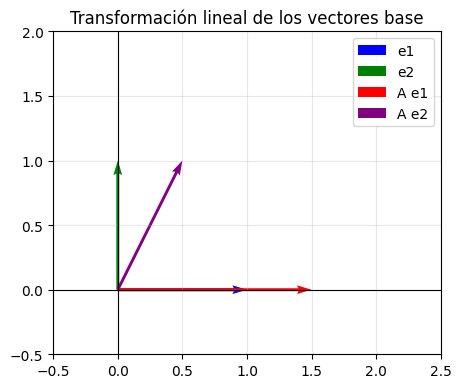

In [50]:
A = np.array([[1.5, 0.5],
              [0.0, 1.0]])

e1 = np.array([1, 0])
e2 = np.array([0, 1])

Ae1 = A @ e1
Ae2 = A @ e2

plt.figure(figsize=(5, 5))
plt.axhline(0, linewidth=0.8, color="black")
plt.axvline(0, linewidth=0.8, color="black")
plt.grid(True, alpha=0.3)

# Vectores originales
plt.quiver(0, 0, e1[0], e1[1], angles="xy", scale_units="xy", scale=1, color="blue", label="e1")
plt.quiver(0, 0, e2[0], e2[1], angles="xy", scale_units="xy", scale=1, color="green", label="e2")

# Vectores transformados
plt.quiver(0, 0, Ae1[0], Ae1[1], angles="xy", scale_units="xy", scale=1, color="red", label="A e1")
plt.quiver(0, 0, Ae2[0], Ae2[1], angles="xy", scale_units="xy", scale=1, color="purple", label="A e2")

plt.xlim(-0.5, 2.5)
plt.ylim(-0.5, 2.0)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.title("Transformación lineal de los vectores base")
plt.show()


# 5. Matrices especiales

Algunas matrices aparecen con frecuencia en análisis numérico:

- Matriz identidad $I$: no cambia un vector o matriz compatible.
- Matriz diagonal: solo tiene valores en la diagonal principal.
- Matriz triangular: importante para sustitución hacia adelante o hacia atrás.
- Matriz cero: todos sus elementos son cero.


In [51]:
I = np.eye(3)
D = np.diag([2, -1, 5])
U = np.triu(np.array([[1, 2, 3],
                      [4, 5, 6],
                      [7, 8, 9]]))
Z = np.zeros((3, 3))

print("Identidad I =\n", I)
print("\nDiagonal D =\n", D)
print("\nTriangular superior U =\n", U)
print("\nCero Z =\n", Z)


Identidad I =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Diagonal D =
 [[ 2  0  0]
 [ 0 -1  0]
 [ 0  0  5]]

Triangular superior U =
 [[1 2 3]
 [0 5 6]
 [0 0 9]]

Cero Z =
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


## Creación rápida de matrices en NumPy


In [54]:
matriz_ceros = np.zeros((3, 3))
matriz_unos = np.ones((2, 4))
matriz_identidad = np.eye(4)
matriz_aleatoria = np.random.rand(3, 3)
matriz_rango = np.arange(1, 11).reshape((2, 5))

print("Matriz de ceros:\n", matriz_ceros)
print("\nMatriz de unos:\n", matriz_unos)
print("\nMatriz identidad:\n", matriz_identidad)
print("\nMatriz aleatoria:\n", matriz_aleatoria)
print("\nMatriz con arange y reshape:\n", matriz_rango)


Matriz de ceros:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Matriz de unos:
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]]

Matriz identidad:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Matriz aleatoria:
 [[0.17010975 0.47120904 0.72184385]
 [0.93772275 0.77014479 0.02290072]
 [0.58913843 0.44364878 0.941846  ]]

Matriz con arange y reshape:
 [[ 1  2  3  4  5]
 [ 6  7  8  9 10]]


# 6. Determinante, rango e inversa

Para una matriz cuadrada $A$:

- Si $\det(A)=0$, la matriz es singular y no tiene inversa.
- Si $\det(A)\neq 0$, la matriz es no singular.
- El rango indica cuántas filas o columnas linealmente independientes tiene la matriz.
- Una matriz cuadrada $n \times n$ tiene rango completo si su rango es $n$.

En análisis numérico, la inversa rara vez se usa directamente para resolver sistemas; normalmente se prefieren métodos como eliminación gaussiana o factorización LU.


In [ ]:
A = np.array([[4, 7],
              [2, 6]], dtype=float)

print("A =\n", A)
print("det(A):", det(A))
print("rango(A):", matrix_rank(A))

A_inv = inv(A)

print("A^{-1} =\n", A_inv)
print("A @ A^{-1} =\n", A @ A_inv)
print("¿A @ A^{-1} ≈ I?", np.allclose(A @ A_inv, np.eye(2)))


A =
 [[4. 7.]
 [2. 6.]]
det(A): 10.000000000000002
rango(A): 2
A^{-1} =
 [[ 0.6 -0.7]
 [-0.2  0.4]]
A @ A^{-1} =
 [[ 1.00000000e+00 -1.11022302e-16]
 [ 1.11022302e-16  1.00000000e+00]]
¿A @ A^{-1} ≈ I? True


## Matriz singular

Una matriz singular no tiene inversa. En este ejemplo, la segunda fila es el doble de la primera.


In [ ]:
S = np.array([[1, 2],
              [2, 4]], dtype=float)

print("S =\n", S)
print("det(S):", det(S))
print("rango(S):", matrix_rank(S))

try:
    inv(S)
except np.linalg.LinAlgError as error:
    print("No se puede invertir S:")
    print(error)


S =
 [[1. 2.]
 [2. 4.]]
det(S): 0.0
rango(S): 1
No se puede invertir S:
Singular matrix


# 7. Número de condición

El número de condición mide qué tan sensible es una matriz a errores pequeños.

De forma intuitiva:

- condición pequeña: el problema suele ser más estable;
- condición grande: pequeños cambios pueden producir grandes diferencias en el resultado.

Esto será importante al estudiar sistemas lineales.


In [ ]:
A_buena = np.array([[3, 1],
                    [1, 2]], dtype=float)

A_mala = np.array([[1, 1],
                   [1, 1.0001]], dtype=float)

print("cond(A_buena):", cond(A_buena))
print("cond(A_mala): ", cond(A_mala))


cond(A_buena): 2.618033988749896
cond(A_mala):  40002.00007491187


## Sensibilidad ante cambios pequeños

Aquí usamos la misma matriz mal condicionada con dos vectores $b$ muy parecidos. El cambio pequeño en $b$ puede producir un cambio grande en la solución $x$.


In [ ]:
A = A_mala
b1 = np.array([2, 2.0001])
b2 = np.array([2, 2.0002])

x1 = np.linalg.solve(A, b1)
x2 = np.linalg.solve(A, b2)

print("x1 =", x1)
print("x2 =", x2)
print("Cambio en b:", norm(b2 - b1))
print("Cambio en x:", norm(x2 - x1))


x1 = [1. 1.]
x2 = [0. 2.]
Cambio en b: 9.999999999976694e-05
Cambio en x: 1.4142135623699548


# 8. Matriz aumentada y rango

Para un sistema lineal:

$$
Ax = b
$$

la matriz aumentada se escribe:

$$
[A \mid b].
$$

Antes de resolver un sistema, conviene revisar:

- dimensión de $A$,
- dimensión de $b$,
- rango de $A$,
- rango de $[A \mid b]$,
- número de condición de $A$ si $A$ es cuadrada.


In [ ]:
A = np.array([[1, 1, 0],
              [0, 1, 0],
              [1, 0, 1]], dtype=float)

b = np.array([[1],
              [2],
              [1]], dtype=float)

A_aumentada = np.concatenate((A, b), axis=1)

print("A =\n", A)
print("b =\n", b)
print("[A | b] =\n", A_aumentada)
print("rango(A):", matrix_rank(A))
print("rango([A | b]):", matrix_rank(A_aumentada))
print("cond(A):", cond(A))


A =
 [[1. 1. 0.]
 [0. 1. 0.]
 [1. 0. 1.]]
b =
 [[1.]
 [2.]
 [1.]]
[A | b] =
 [[1. 1. 0. 1.]
 [0. 1. 0. 2.]
 [1. 0. 1. 1.]]
rango(A): 3
rango([A | b]): 3
cond(A): 4.048917339522305


# 9.

| Pregunta | Comando útil |
|---|---|
| ¿Qué dimensión tiene la matriz? | `A.shape` |
| ¿El vector tiene dimensión compatible? | `A.shape`, `b.shape` |
| ¿La matriz es cuadrada? | `A.shape[0] == A.shape[1]` |
| ¿Tiene rango completo? | `np.linalg.matrix_rank(A)` |
| ¿Es singular o casi singular? | `np.linalg.det(A)`, `np.linalg.cond(A)` |
| ¿El producto está bien definido? | comparar dimensiones internas |
| ¿Estoy usando producto matricial? | `A @ B`, no `A * B` |
